In [1]:
#remotes::install_github("jinworks/CellChat@88c2e13")

suppressPackageStartupMessages({
    library(CellChat)
    library(zellkonverter)
    library(SingleCellExperiment())
})



In [2]:
library(tidyr)
library(tibble)


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand


The following object is masked from ‘package:igraph’:

    crossing



Attaching package: ‘tibble’


The following object is masked from ‘package:igraph’:

    as_data_frame




In [3]:
dist_out_dir <- "/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance"
dist_out_dir_cellchat <- "/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance/cellchat_tls-category"
plot_out_dir <- file.path(dist_out_dir_cellchat, "plots")

## Load cellchat results

In [30]:
# path =  file.path(dist_out_dir_cellchat, "cellchat_HDM_day3_trim_0.1_intrange_50_popsize_FALSE.rds")
path =  file.path(dist_out_dir_cellchat, "cellchat_HDM_day3_trim_0.2_intrange_50_contact_FALSE_popsize_FALSE.rds")
cellchat <- readRDS(path)

### Adjust cell label order for plotting

In [31]:
# First adjust the cell label order
label_df <- read.csv("/home/workspace/spatial_tls_manuscript/inputs/20250519_mouse_lung_label_mapping_ordered.csv")

# Get the current labels in the CellChat object
cellchat_labels <- unique(cellchat@idents)

# Keep only labels that are in the cellchat object
ordered_labels <- label_df$label_fine[label_df$label_fine %in% cellchat_labels]

# Optional: Append custom labels (if needed)
extra_labels <- c('CD4 act (tls surround)','CD4 act (tls outer)', 'CD4 act (tls core)')
cell_order <- c(as.character(ordered_labels), extra_labels)
cell_order <- rev(cell_order)

# Update the CellChat object with new label order
cellchat@meta$labels <- factor(cellchat@idents, levels = cell_order)
cellchat <- updateClusterLabels(cellchat, new.order = cell_order)

Only reorder cell groups but do not rename cell groups!

Reorder cell groups! 



The cell group order before reordering is  AT1 AT2 Alv Mf Art B cell CD4 act (tls core) CD4 act (tls outer) CD4 act (tls surround) CD4 naive CD8 act CD8 naive Cap Cap-a Ccr7+ cDC2 Ccr7- cDC2 Ciliated Club Col13a1+ fibroblast Col14a1+ fibroblast ILC2 Int Mf Lymph Mesothelial Mono Myofibroblast NK cell Neut Pericyte 1 Pericyte 2 Plasmablast SMC Vein cDC1 gd T cell 
The cell group order after reordering is  CD4 act (tls core) CD4 act (tls outer) CD4 act (tls surround) CD4 naive CD8 act CD8 naive ILC2 gd T cell NK cell Plasmablast B cell Ccr7+ cDC2 Ccr7- cDC2 cDC1 Neut Alv Mf Int Mf Mono Lymph Vein Art Cap-a Cap Mesothelial Pericyte 2 Pericyte 1 Myofibroblast Col14a1+ fibroblast Col13a1+ fibroblast SMC Ciliated Club AT2 AT1 


We now re-run computeCommunProbPathway`,`aggregateNet`, and `netAnalysis_computeCentrality`...



### Run netAnalysis_computeCentrality

In [32]:
cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP")

## Plot

In [33]:
# create_plots <- function(cellchat) {
#     # change the order of the labels
#     cellchat@meta$labels <- forcats::fct_relevel(cellchat@meta$labels, 'CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)')
#     cellchat <- updateClusterLabels(cellchat, new.order = levels(cellchat@meta$labels))

#     cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP")

#     pdf(file = file.path(plot_out_dir, "signaling_role_populationsize_FALSE.pdf"))
#     plot(netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming"))
#     plot.new()
#     plot(netAnalysis_signalingRole_heatmap(cellchat, pattern = "outgoing"))
#     dev.off()
# }

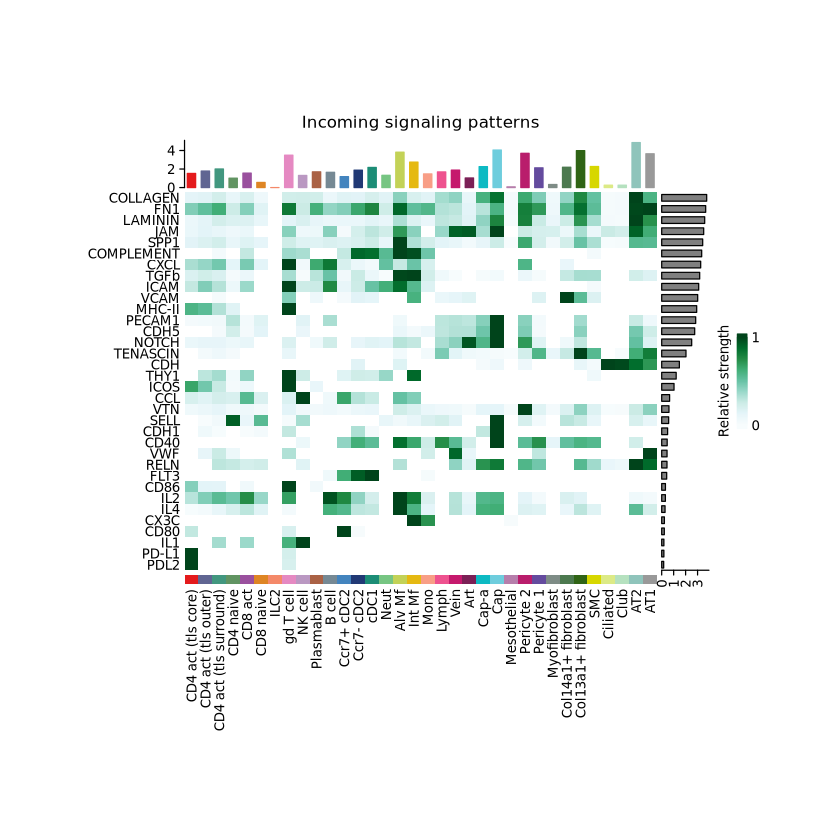

In [34]:
plot(netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming"))

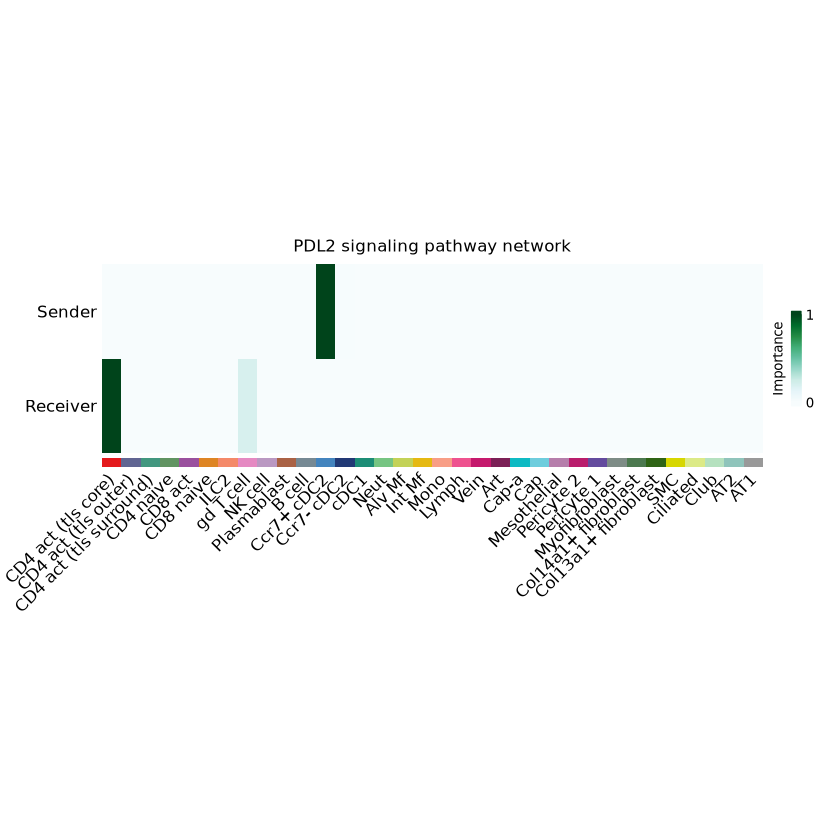

In [35]:
pathways.show <- c("PDL2")



netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)


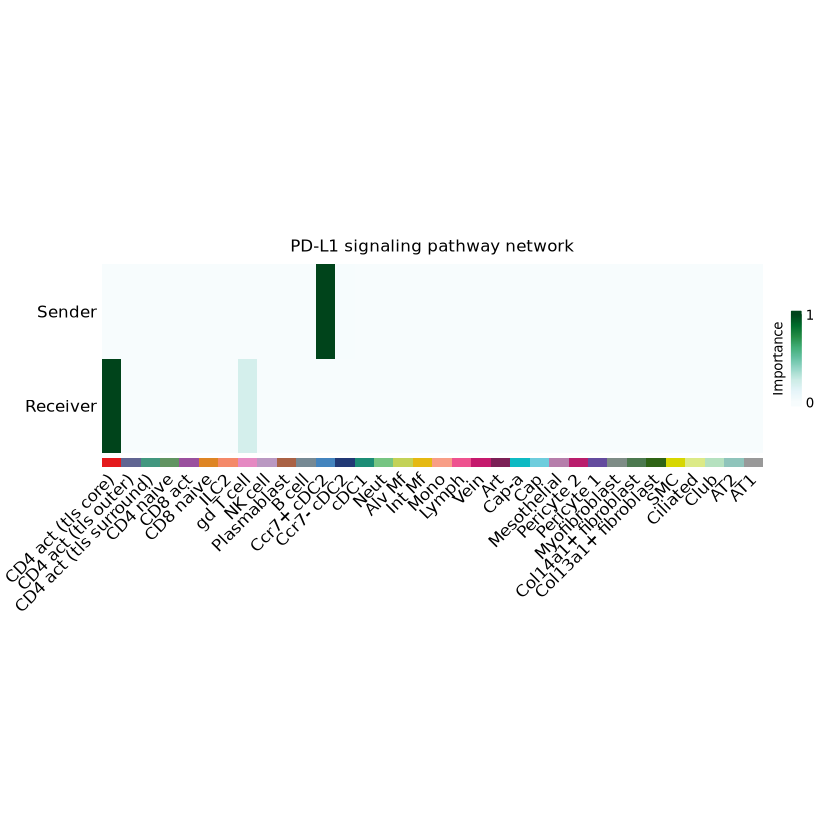

In [36]:
pathways.show <- c("PD-L1")
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 14, height = 4, font.size = 10)

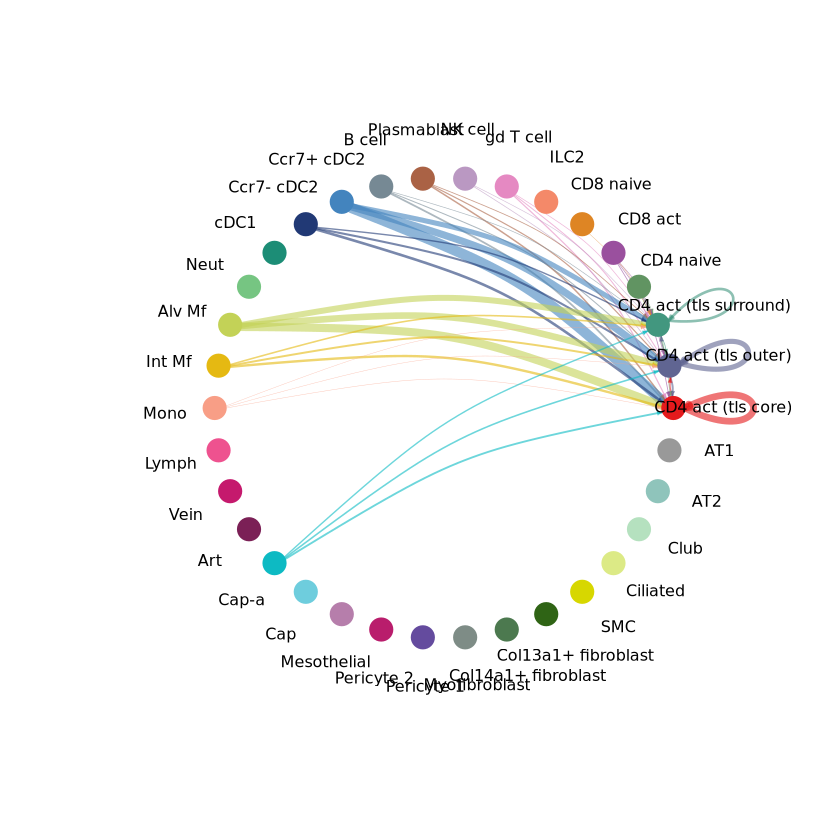

In [28]:
pathways.show <- c("PD-L1")
p<- netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    # cell.order = cell_order, 
                    layout = "circle")

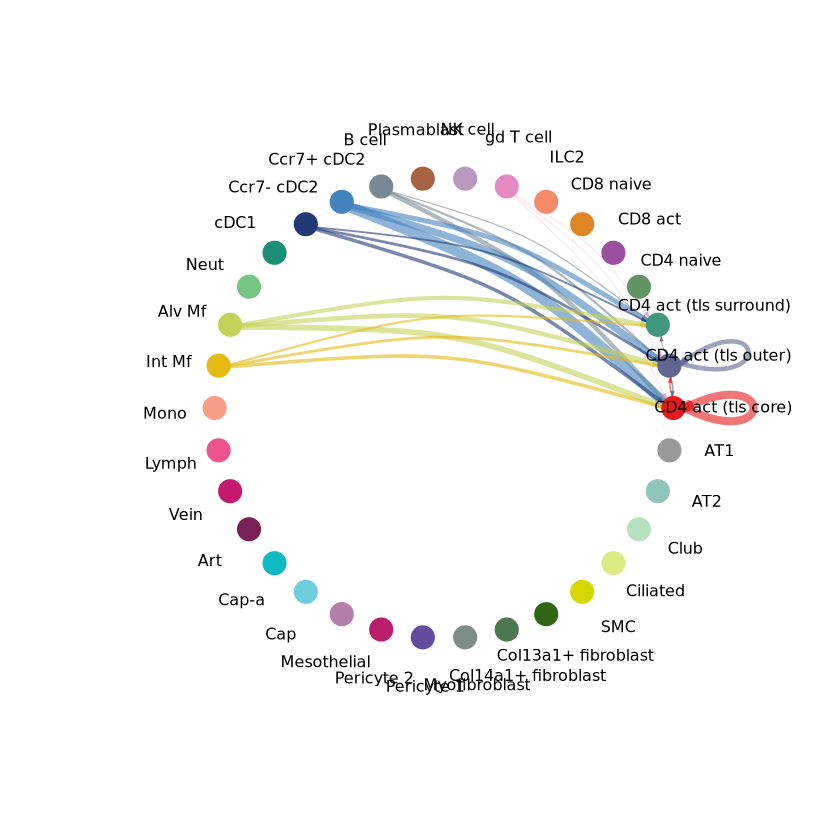

In [29]:
pathways.show <- c("PDL2")
p<- netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    # cell.order = cell_order, 
                    layout = "circle")

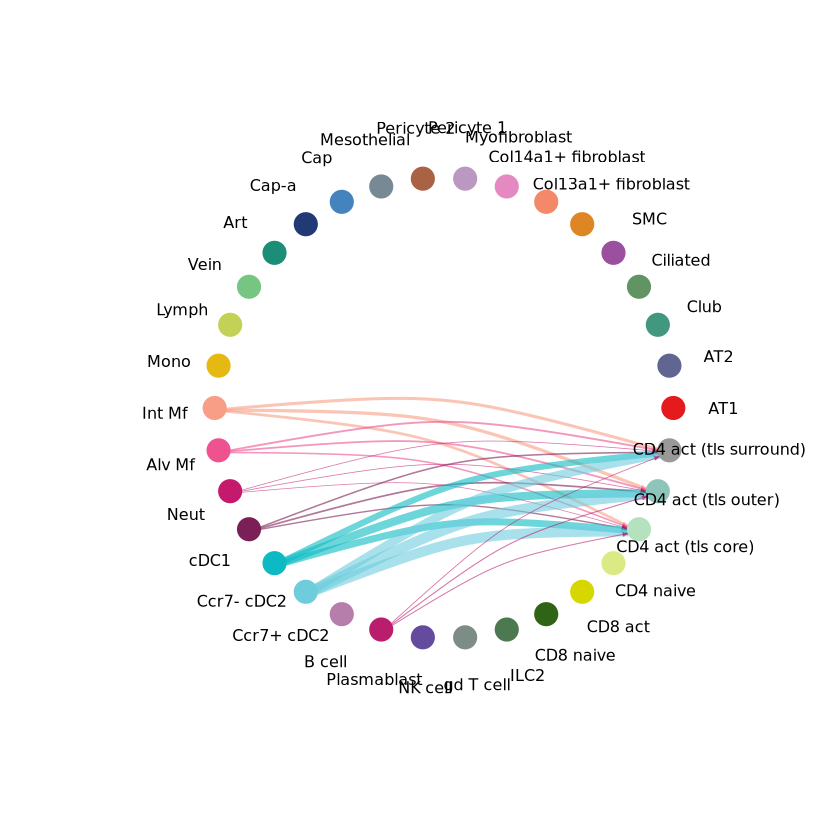

In [15]:
pathways.show <- c("CD80")
p<- netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    # cell.order = cell_order, 
                    layout = "circle")

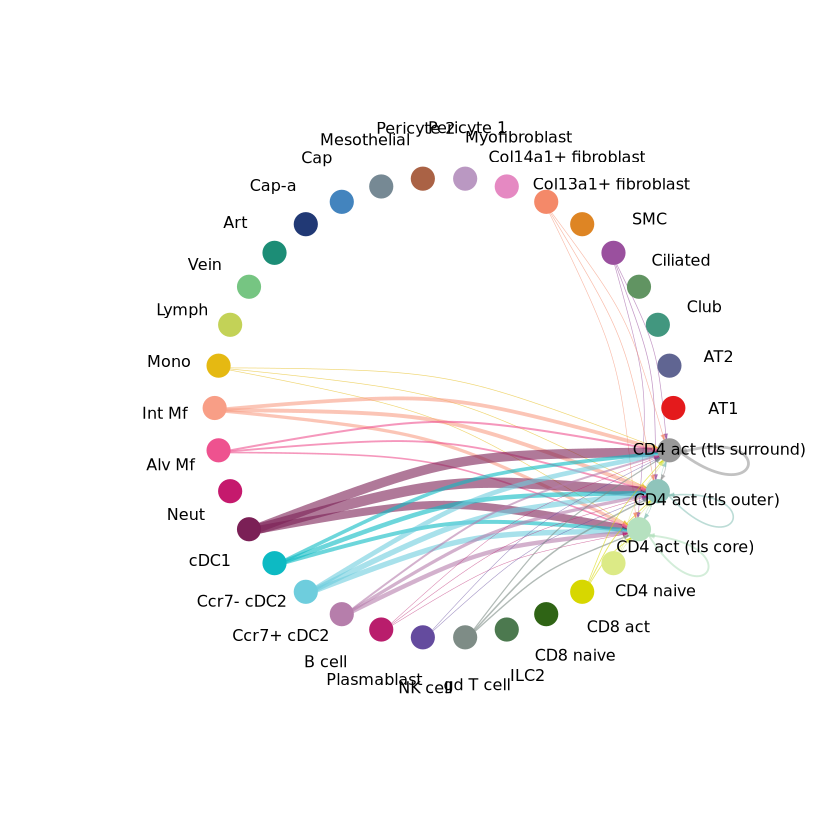

In [16]:
pathways.show <- c("CD86")
p<- netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    # cell.order = cell_order, 
                    layout = "circle")

Comparing communications on a single object 




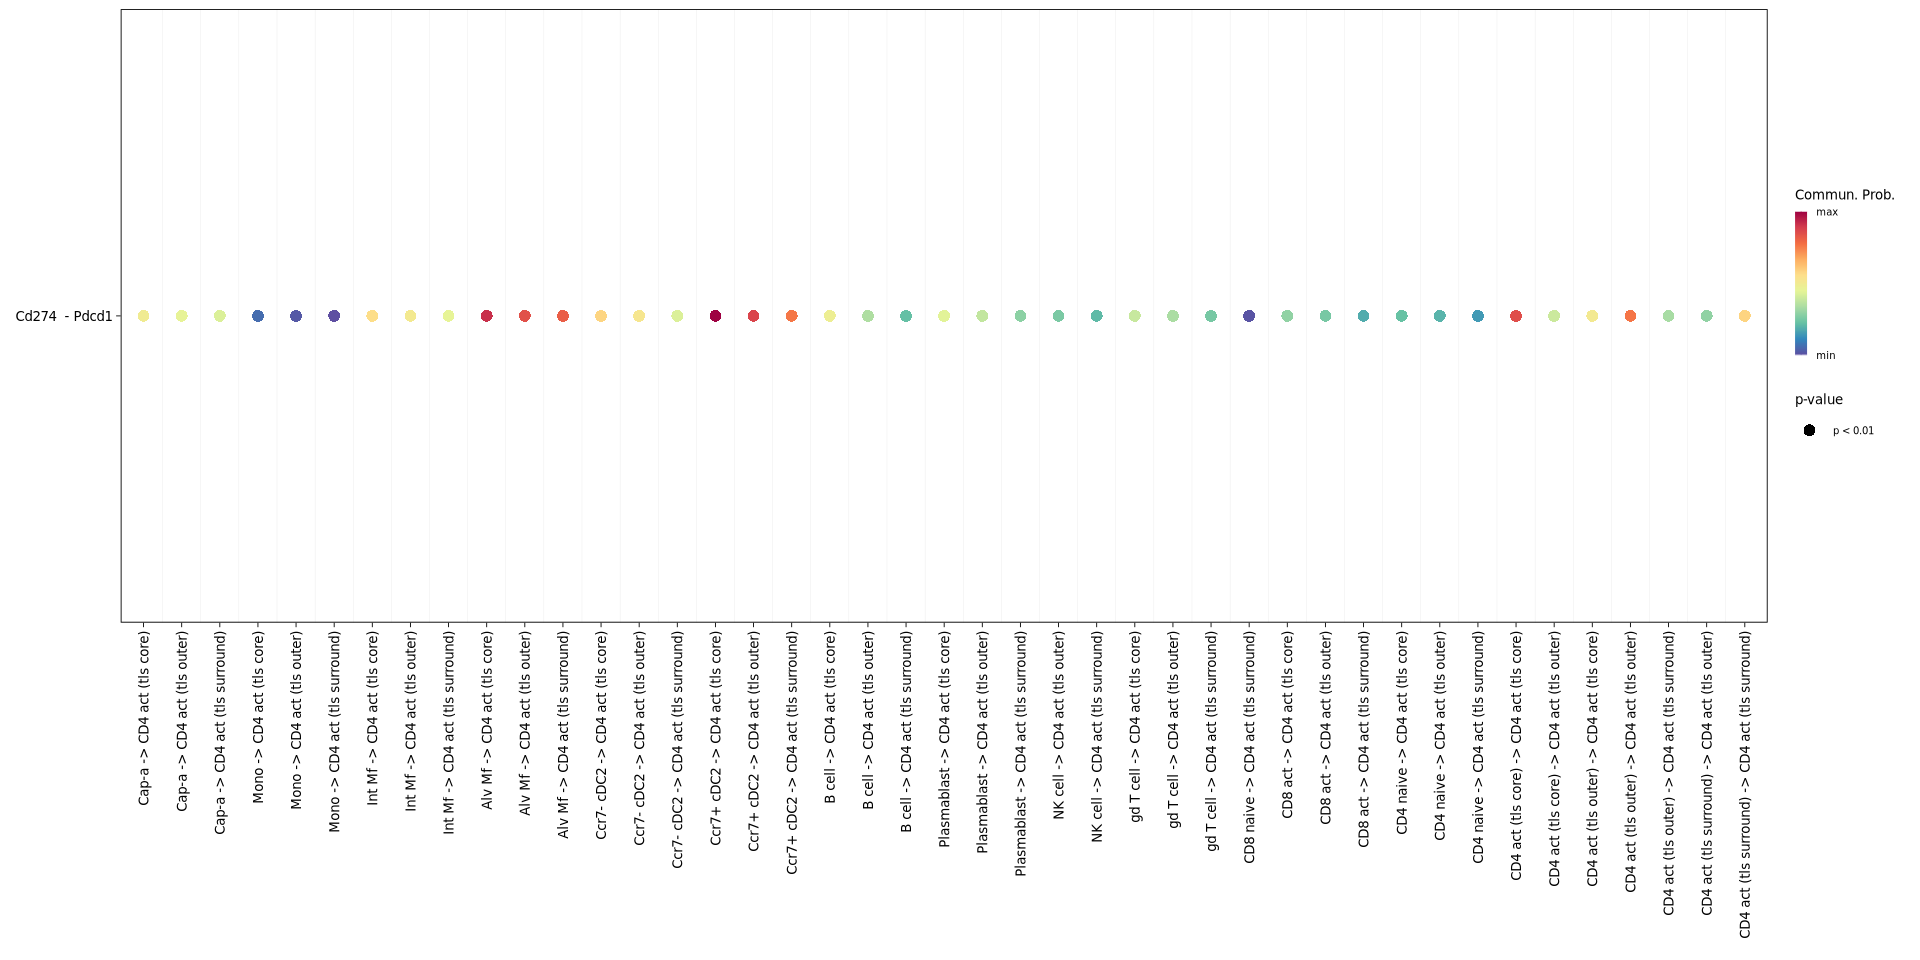

In [17]:
options(repr.plot.width = 16, repr.plot.height = 8)
netVisual_bubble(
  cellchat,
  # sources.use = sources,
  targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
  signaling = "PD-L1",  
    # pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)

Comparing communications on a single object 




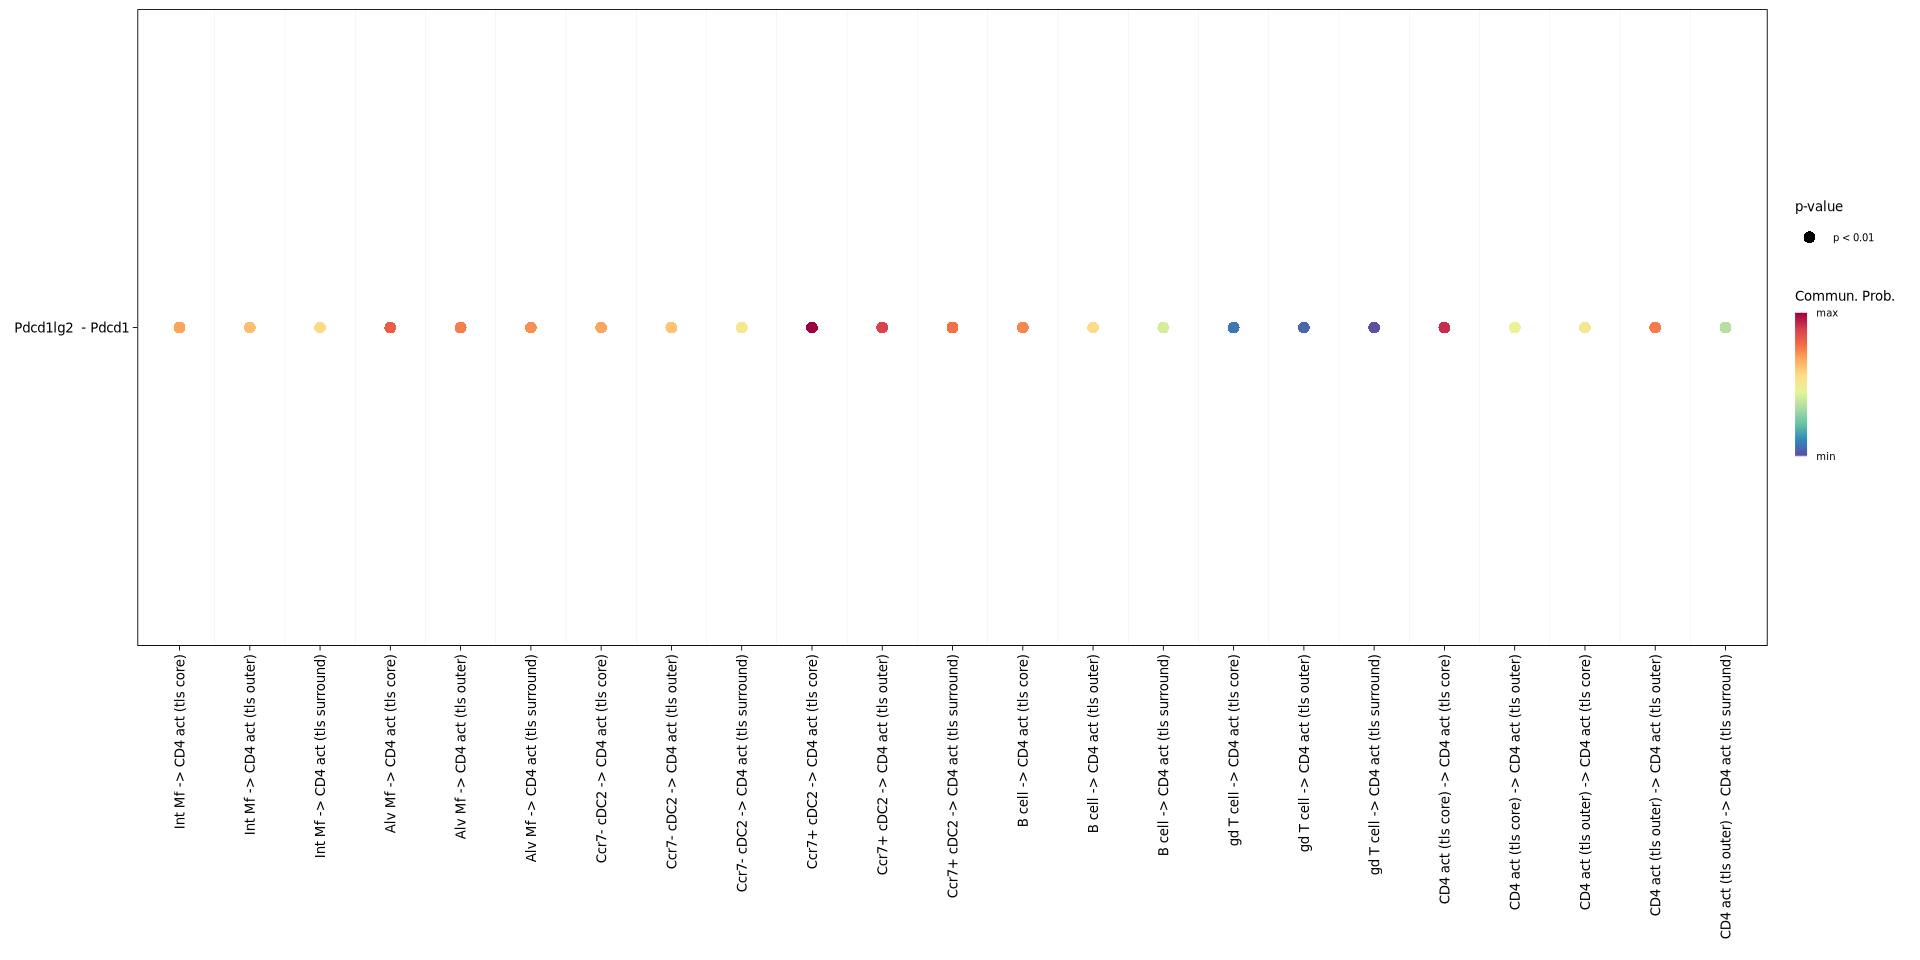

In [18]:
options(repr.plot.width = 16, repr.plot.height = 8)
netVisual_bubble(
  cellchat,
  # sources.use = sources,
  targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
  signaling = "PDL2",  
    # pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)